# Eniac Order Data: Cleaning, Quality Assessment & Storytelling

Eniac is an online retailer of Apple accessories and peripherals. This notebook works through the raw order export end to end: assessing data quality issues, fixing them with documented and testable rules, and then using the cleaned data to answer a few questions a growth or ops team would actually ask — where the revenue comes from, how much demand never converts into a sale, and which data points can't be trusted.

**Tables:** `orders` (one row per order, with status and total paid), `orderlines` (one row per product within an order, with quantity and unit price), `products` (catalogue with price and promo price), `brands` (brand code → brand name lookup).


In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from cleaning import fix_price_string, clean_orders, clean_orderlines, clean_products

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110


## 1. Load the raw data

In [2]:
orders_raw = pd.read_csv('../data/raw/orders.csv')
orderlines_raw = pd.read_csv('../data/raw/orderlines.csv')
products_raw = pd.read_csv('../data/raw/products.csv')
brands = pd.read_csv('../data/raw/brands.csv')

for name, df in [('orders', orders_raw), ('orderlines', orderlines_raw),
                  ('products', products_raw), ('brands', brands)]:
    print(f"{name:12s} {df.shape}")


orders       (226909, 4)
orderlines   (293983, 7)
products     (19326, 7)
brands       (187, 2)


## 2. Initial data quality assessment

Before touching anything, it's worth looking at what's actually broken.

In [3]:
print(orders_raw.dtypes)
print()
print("Missing values:")
print(orders_raw.isna().sum())
print()
print("Order status breakdown:")
print(orders_raw['state'].value_counts())


order_id          int64
created_date        str
total_paid      float64
state               str
dtype: object

Missing values:
order_id        0
created_date    0
total_paid      5
state           0
dtype: int64

Order status breakdown:
state
Shopping Basket    117809
Completed           46605
Place Order         40883
Pending             14379
Cancelled            7233
Name: count, dtype: int64


`orders` looks clean enough — a handful of missing `total_paid` values, and a `state` column that's clearly a sales funnel rather than a flat category (more on that in the storytelling section).

Now `orderlines`, where the real problems start:

In [4]:
print(orderlines_raw.dtypes)
print()
print("unit_price is stored as text, not a number. A sample of unusual values:")
print(orderlines_raw[orderlines_raw['unit_price'].str.count(r'\.') >= 2]['unit_price'].head(8).tolist())


id                  int64
id_order            int64
product_id          int64
product_quantity    int64
sku                   str
unit_price            str
date                  str
dtype: object

unit_price is stored as text, not a number. A sample of unusual values:
['1.137.99', '2.565.99', '3.278.99', '2.616.99', '2.873.99', '2.780.99', '2.316.99', '2.558.99']


**The bug:** prices above roughly €1,000 are written with an *extra* period acting as a thousands separator — `"2.565.99"` is meant to be read as €2,565.99, not as the (nonsensical) literal float `2.565.99`. A naive `pd.to_numeric()` call on this column fails outright for ~36k rows (12% of all order lines).

The fix used here (`fix_price_string` in `src/cleaning.py`): for any string with more than one `.`, treat all but the last one as thousands separators and strip them before converting to float.


In [5]:
examples = ['1.137.99', '399.00', '18.99', '2.565.99']
for e in examples:
    print(f"{e!r:>12} -> {fix_price_string(e)}")


  '1.137.99' -> 1137.99
    '399.00' -> 399.0
     '18.99' -> 18.99
  '2.565.99' -> 2565.99


That handles the formatting bug, but it doesn't catch every bad value — a few entries are still implausible after the fix (a price of 0, or a price wildly different from what the same SKU normally sells for). Those get flagged rather than silently trusted:

In [6]:
orderlines_clean = clean_orderlines(orderlines_raw)

n_total = len(orderlines_clean)
n_unreliable = (~orderlines_clean['price_is_reliable']).sum()
print(f"{n_unreliable:,} of {n_total:,} order lines ({n_unreliable/n_total:.1%}) have a price flagged as unreliable")
print("(price <= 0, or more than 5x away from that SKU's own median price)")


1,140 of 293,983 order lines (0.4%) have a price flagged as unreliable
(price <= 0, or more than 5x away from that SKU's own median price)


### What about `promo_price` in the products table?

A promotional price should logically be *lower* than the regular price. After applying the same thousands-separator fix to both columns, that's not what the data shows:


In [7]:
products_temp = products_raw.copy()
products_temp['price_fixed'] = products_temp['price'].apply(fix_price_string)
products_temp['promo_fixed'] = products_temp['promo_price'].apply(fix_price_string)

ratio = (products_temp['promo_fixed'] / products_temp['price_fixed']).dropna()
pct_higher = (ratio > 1).mean()

print(f"promo_price is HIGHER than price for {pct_higher:.1%} of products")
print(f"median promo/price ratio: {ratio.median():.2f}x")


promo_price is HIGHER than price for 85.6% of products
median promo/price ratio: 8.48x


That's not a real-world promo pattern — it looks like `promo_price` was corrupted somewhere upstream (possibly in scraping or export), and there's no defensible rule to reconstruct the intended value from what's left. Rather than force a fix or use a column that fails a basic sanity check, **`promo_price` is dropped** (see `clean_products` in `src/cleaning.py`). This is also a reminder that a clean-looking numeric column isn't automatically a trustworthy one.

## 3. Applying the cleaning

In [8]:
orders_clean = clean_orders(orders_raw)
products_clean = clean_products(products_raw)

print(f"orders: {len(orders_raw):,} -> {len(orders_clean):,} rows after dropping missing total_paid")
print(f"orderlines: unit_price now numeric, {orderlines_clean['unit_price'].notna().mean():.1%} parsed successfully")
print(f"products: promo_price column dropped, price now numeric")


clean_orders: dropped 5 rows with missing total_paid
orders: 226,909 -> 226,904 rows after dropping missing total_paid
orderlines: unit_price now numeric, 100.0% parsed successfully
products: promo_price column dropped, price now numeric


## 4. Putting it together for analysis

For the revenue questions below, only `Completed` orders and order lines with a `price_is_reliable` flag of `True` are used — abandoned baskets and flagged data points would distort every downstream number.

In [9]:
completed_ids = set(orders_clean.loc[orders_clean['state'] == 'Completed', 'order_id'])

ol = orderlines_clean[
    orderlines_clean['id_order'].isin(completed_ids) &
    orderlines_clean['price_is_reliable']
].copy()

ol = ol.merge(brands.rename(columns={'short': 'brand_code', 'long': 'brand'}),
              on='brand_code', how='left')

print(f"{len(ol):,} reliable order lines across {ol['id_order'].nunique():,} completed orders")


62,047 reliable order lines across 46,557 completed orders


## 5. Storytelling

### 5.1 Where does demand actually go? (the conversion funnel)

Only about a fifth of all orders in this dataset ever reach `Completed`. That's worth visualising on its own before looking at revenue, since every number after this point only covers that smaller slice.

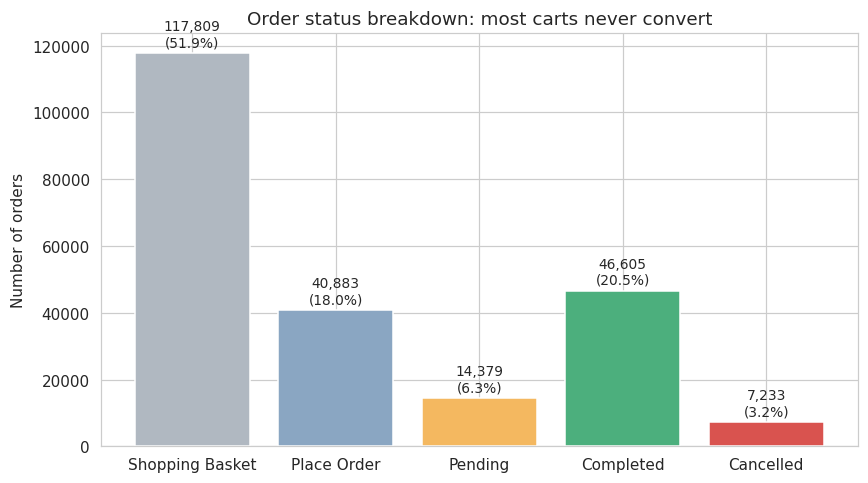

In [10]:
funnel_order = ['Shopping Basket', 'Place Order', 'Pending', 'Completed', 'Cancelled']
funnel = orders_raw['state'].value_counts().reindex(funnel_order)

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ['#b0b8c1', '#8aa6c2', '#f4b860', '#4caf7d', '#d9534f']
ax.bar(funnel.index, funnel.values, color=colors)
for i, v in enumerate(funnel.values):
    ax.text(i, v + 2000, f"{v:,}\n({v/funnel.sum():.1%})", ha='center', fontsize=9)
ax.set_ylabel('Number of orders')
ax.set_title('Order status breakdown: most carts never convert')
plt.tight_layout()
plt.savefig('../exports/order_status_funnel.png', dpi=150)
plt.show()


### 5.2 Monthly revenue trend

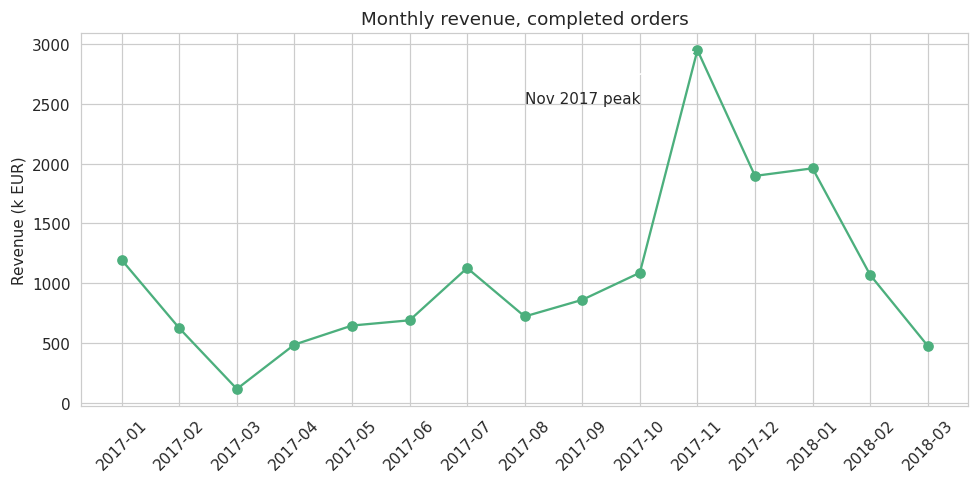

  month  num_orders    revenue
2017-01        5135 1194364.76
2017-02        2274  623896.30
2017-03         202  115937.31
2017-04        1632  486962.21
2017-05        1893  646147.86
2017-06        1607  690049.94
2017-07        3443 1127176.79
2017-08        2350  722055.81
2017-09        2183  861186.73
2017-10        3136 1087801.23
2017-11        7189 2949497.10
2017-12        5508 1897518.73
2018-01        5203 1960899.26
2018-02        3335 1069712.71
2018-03        1515  476872.50


In [11]:
completed = orders_clean[orders_clean['state'] == 'Completed'].copy()
completed['month'] = completed['created_date'].dt.to_period('M').astype(str)
monthly = completed.groupby('month').agg(num_orders=('order_id', 'count'),
                                          revenue=('total_paid', 'sum')).reset_index()
monthly.to_csv('../exports/monthly_revenue.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(monthly['month'], monthly['revenue'] / 1000, marker='o', color='#4caf7d')
ax.set_ylabel('Revenue (k EUR)')
ax.set_title('Monthly revenue, completed orders')
ax.annotate('Nov 2017 peak', xy=(10, monthly['revenue'].iloc[10]/1000),
            xytext=(7, monthly['revenue'].max()/1000 * 0.85),
            arrowprops=dict(arrowstyle='->'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../exports/monthly_revenue.png', dpi=150)
plt.show()

print(monthly.to_string(index=False))


November 2017 stands out clearly — consistent with a Black Friday / holiday-season effect. March 2018 is a partial month (the export cuts off mid-month), so its lower total isn't a real decline.

### 5.3 Brand concentration

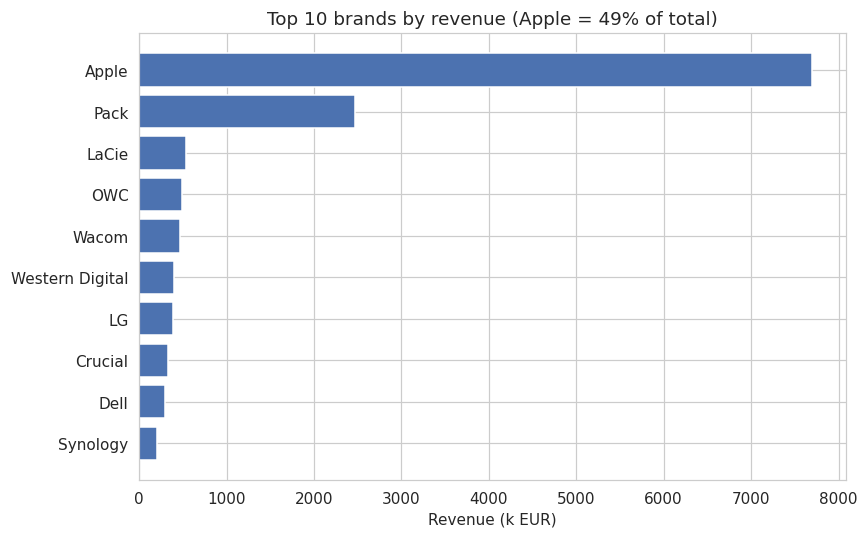

In [12]:
brand_rev = ol.groupby('brand').agg(num_lines=('id', 'count'),
                                     revenue=('line_revenue', 'sum')).reset_index()
brand_rev = brand_rev.sort_values('revenue', ascending=False)
brand_rev.to_csv('../exports/brand_revenue.csv', index=False)

top10 = brand_rev.head(10)
apple_share = brand_rev.loc[brand_rev['brand'] == 'Apple', 'revenue'].sum() / brand_rev['revenue'].sum()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top10['brand'][::-1], top10['revenue'][::-1] / 1000, color='#4c72b0')
ax.set_xlabel('Revenue (k EUR)')
ax.set_title(f'Top 10 brands by revenue (Apple = {apple_share:.0%} of total)')
plt.tight_layout()
plt.savefig('../exports/top_brands_revenue.png', dpi=150)
plt.show()


Apple alone accounts for roughly half of all product revenue, which makes sense for an Apple-accessories retailer — but it's also a concentration risk worth flagging: any change in Apple's product line, pricing, or supply could move the whole business.

### 5.4 Order value distribution

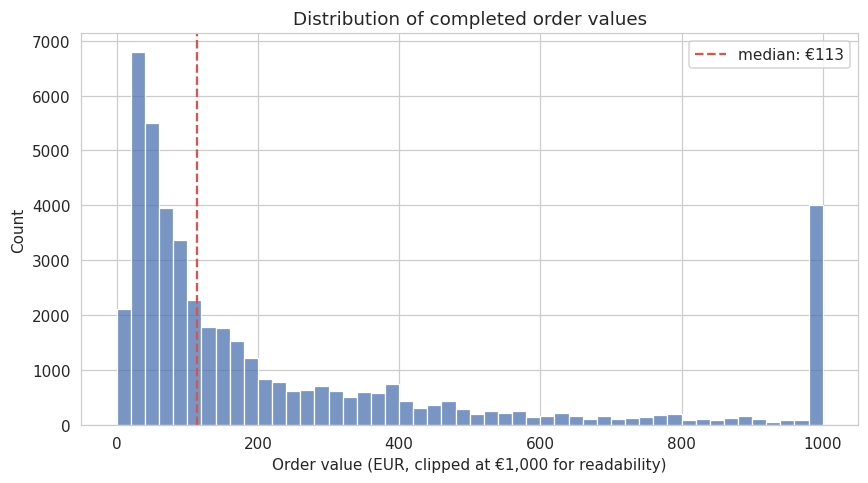

count    46605.00
mean       341.38
std        625.53
min          0.00
25%         50.98
50%        113.23
75%        333.97
max      13387.78
Name: total_paid, dtype: float64


In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(completed['total_paid'].clip(upper=1000), bins=50, color='#4c72b0', ax=ax)
ax.axvline(completed['total_paid'].median(), color='#d9534f', linestyle='--', label=f"median: €{completed['total_paid'].median():.0f}")
ax.set_xlabel('Order value (EUR, clipped at €1,000 for readability)')
ax.set_title('Distribution of completed order values')
ax.legend()
plt.tight_layout()
plt.savefig('../exports/order_value_distribution.png', dpi=150)
plt.show()

print(completed['total_paid'].describe().round(2))


## 6. Key takeaways

- **Conversion is the bigger story than revenue.** Only ~20.5% of all orders ever reach `Completed`; over half never leave the shopping basket stage. Before optimising prices or marketing spend, it's worth understanding *why* — checkout friction, payment failures, and stock issues would all show up here but need a different dataset (e.g. session-level event data) to diagnose.
- **Revenue is seasonal and brand-concentrated.** November 2017 alone brought in roughly double a typical month's revenue, and Apple products account for about half of total revenue — both useful inputs for inventory and cash-flow planning.
- **Not all "clean-looking" data is trustworthy.** `promo_price` parses fine as a number but fails a basic business-logic check (it's higher than the regular price 85% of the time). Catching that before using it in any pricing analysis prevented a wrong conclusion from going further downstream.
- **A documented, testable cleaning rule beats a one-off fix.** The thousands-separator issue affected 12% of all order lines; wrapping the fix in `fix_price_string()` makes it auditable and reusable on future exports rather than redone by hand each time.
